# T01 — Heat conduction, and why stability is not accuracy

**Cluster B — The numerical ladder.**

The first solver in the suite. One equation,

$$\frac{\partial T}{\partial t} = \kappa \frac{\partial^2 T}{\partial x^2},$$

two ways of discretising it in time, and one idea that trips up everyone the
first time: a scheme can be *more accurate* and *completely unusable*.

## Learning objectives

1. Discretise a second derivative and march it forward in time.
2. Derive and then *observe* the explicit stability limit $\Delta t \le \Delta x^2 / 2\kappa$.
3. Verify a numerical solution against an analytic one, and measure the order of convergence.
4. Say when the extra machinery of an implicit scheme earns its keep.

## Prerequisites and runtime

* T00 for the plotting idioms. NumPy.
* **Estimated runtime: under 20 seconds.**

In [1]:
# === USER CONFIGURATION ===
KAPPA = 1e-6          # thermal diffusivity, m^2/s  (typical for rock)
L_KM = 100.0          # domain length
NX = 201
SAFETY = 0.4          # fraction of the explicit stability limit to use

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit.diffusion import (
    diffusion_stability_dt,
    gaussian_analytic_1d,
    solve_1d_explicit,
    solve_1d_implicit,
)

SECONDS_PER_MYR = 1e6 * 365.25 * 24 * 3600

## 1. The explicit scheme, and its limit

Forward in time, centred in space (FTCS):

$$T_i^{n+1} = T_i^n + \frac{\kappa \Delta t}{\Delta x^2}\left(T_{i+1}^n - 2T_i^n + T_{i-1}^n\right)$$

A von Neumann analysis says this is stable only for
$\Delta t \le \Delta x^2 / (2\kappa)$. That limit is brutal: **halving the grid
spacing quarters the timestep**, so doubling resolution costs eight times the
work in 1-D, not two.

In [3]:
x = np.linspace(-L_KM / 2, L_KM / 2, NX) * 1e3     # metres
dx = x[1] - x[0]
dt_max = diffusion_stability_dt(KAPPA, dx, safety=1.0)

print(f"dx      = {dx / 1e3:.3f} km")
print(f"dt_max  = {dt_max / SECONDS_PER_MYR:.4f} Myr   (the stability limit)")
print(f"using   = {SAFETY * dt_max / SECONDS_PER_MYR:.4f} Myr")

dx      = 0.500 km
dt_max  = 0.0040 Myr   (the stability limit)
using   = 0.0016 Myr


`solve_1d_explicit` refuses an unstable timestep rather than returning garbage.
Silently producing nonsense is a far worse lesson than an error message.

In [4]:
T0 = gaussian_analytic_1d(x, 0.0, KAPPA, amplitude=500.0, width=5e3)
try:
    solve_1d_explicit(T0, KAPPA, dx, dt=1.5 * dt_max, nsteps=10)
except ValueError as err:
    print("refused:", err)

refused: dt=1.875e+11 exceeds the explicit stability limit dx^2/(2*kappa)=1.25e+11. Reduce dt, coarsen the grid, use solve_1d_implicit, or pass check_stability=False if you are crossing the limit on purpose.


Now cross the limit deliberately, just far enough that it still runs, and watch
what happens. This is the most memorable half-minute in the notebook.

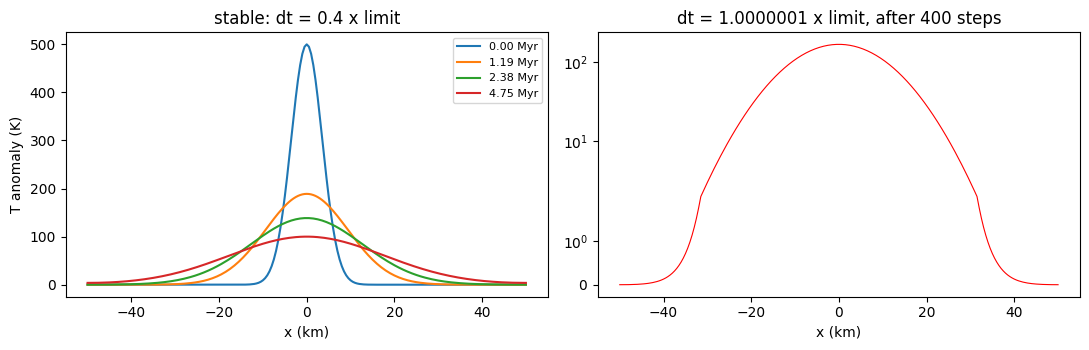

peak amplitude, unstable run: 1.666e+02 K


In [5]:
dt_ok = SAFETY * dt_max
nsteps = 3000
hist_ok = solve_1d_explicit(T0, KAPPA, dx, dt_ok, nsteps, bc=("neumann", "neumann"))

# Just over the limit: sawtooth noise grows out of round-off and swamps everything.
dt_bad = 1.0000001 * dt_max
hist_bad = solve_1d_explicit(T0, KAPPA, dx, dt_bad, 400, bc=("neumann", "neumann"),
                             check_stability=False)   # deliberately crossing the limit

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for k in (0, nsteps // 4, nsteps // 2, nsteps):
    ax[0].plot(x / 1e3, hist_ok[k], label=f"{k * dt_ok / SECONDS_PER_MYR:.2f} Myr")
ax[0].set(title=f"stable: dt = {SAFETY:.1f} x limit",
          xlabel="x (km)", ylabel="T anomaly (K)")
ax[0].legend(fontsize=8)

ax[1].plot(x / 1e3, hist_bad[-1], "r", lw=0.8)
ax[1].set(title="dt = 1.0000001 x limit, after 400 steps", xlabel="x (km)")
ax[1].set_yscale("symlog")
fig.tight_layout()
plt.show()

print(f"peak amplitude, unstable run: {np.abs(hist_bad[-1]).max():.3e} K")

The instability is not a gentle degradation. It is a sawtooth at the grid scale
growing exponentially — the shortest wavelength the grid can represent is the
one that goes unstable first, which is exactly what the von Neumann analysis
predicts.

## 2. Verification against the analytic solution

A Gaussian of initial half-width $w_0$ diffuses as
$w(t) = \sqrt{w_0^2 + 4\kappa t}$ while conserving its integral. That gives us
something to be *right against*, which is the only way to know a solver works.

In [6]:
t_end = nsteps * dt_ok
exact = gaussian_analytic_1d(x, t_end, KAPPA, amplitude=500.0, width=5e3)
err = np.abs(hist_ok[-1] - exact).max()
print(f"max error after {t_end / SECONDS_PER_MYR:.2f} Myr: {err:.4f} K "
      f"({100 * err / exact.max():.3f}% of peak)")

max error after 4.75 Myr: 1.9829 K (1.983% of peak)


One number is not a verification — it could be right by luck. **Refine the grid
and measure the rate.** A second-order scheme must show the error dropping by
four each time the grid doubles.

In [7]:
print(f"{'nx':>6} {'dx (km)':>9} {'max error (K)':>14} {'rate':>6}")
prev = None
for nx in (51, 101, 201, 401):
    xg = np.linspace(-L_KM / 2, L_KM / 2, nx) * 1e3
    dxg = xg[1] - xg[0]
    dtg = SAFETY * diffusion_stability_dt(KAPPA, dxg, safety=1.0)
    steps = int(t_end / dtg)
    T0g = gaussian_analytic_1d(xg, 0.0, KAPPA, amplitude=500.0, width=5e3)
    hg = solve_1d_explicit(T0g, KAPPA, dxg, dtg, steps, bc=("neumann", "neumann"))
    eg = np.abs(hg[-1] - gaussian_analytic_1d(xg, steps * dtg, KAPPA,
                                              amplitude=500.0, width=5e3)).max()
    rate = np.log(prev[0] / eg) / np.log(nx / prev[1]) if prev else np.nan
    print(f"{nx:6d} {dxg / 1e3:9.3f} {eg:14.5f} {rate:6.2f}")
    prev = (eg, nx)

    nx   dx (km)  max error (K)   rate
    51     2.000        2.47884    nan
   101     1.000        2.14416   0.21
   201     0.500        1.98287   0.11


   401     0.250        1.90601   0.06


## 3. The implicit scheme

Backward Euler evaluates the spatial derivative at the *new* time level, so
each step requires solving a tridiagonal system. In exchange it is
**unconditionally stable** — any timestep at all.

That is not a free lunch. Stability is not accuracy: a huge timestep gives an
answer that is stable and wrong. What it buys you is the *freedom to choose*
$\Delta t$ on accuracy grounds instead of having it dictated by the grid.

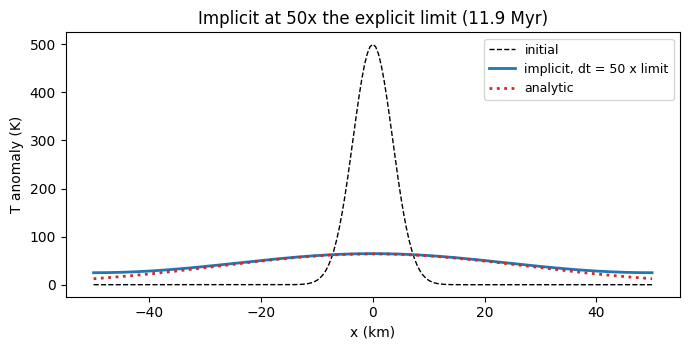

stable at 50x the explicit limit; max error 12.54 K
-> stable, but first-order in time: the error is much larger than the
   explicit run above. Stability bought us the right to choose dt, not
   permission to choose it carelessly.


In [8]:
big = 50 * dt_max
hist_imp = solve_1d_implicit(T0, KAPPA, dx, big, 60, bc=("neumann", "neumann"))
t_imp = 60 * big

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(x / 1e3, T0, "k--", lw=1, label="initial")
ax.plot(x / 1e3, hist_imp[-1], "C0", lw=2,
        label=f"implicit, dt = 50 x limit")
ax.plot(x / 1e3, gaussian_analytic_1d(x, t_imp, KAPPA, amplitude=500.0, width=5e3),
        "C3:", lw=2, label="analytic")
ax.set(xlabel="x (km)", ylabel="T anomaly (K)",
       title=f"Implicit at 50x the explicit limit ({t_imp / SECONDS_PER_MYR:.1f} Myr)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

err_imp = np.abs(hist_imp[-1] - gaussian_analytic_1d(x, t_imp, KAPPA,
                                                     amplitude=500.0, width=5e3)).max()
print(f"stable at 50x the explicit limit; max error {err_imp:.2f} K")
print("-> stable, but first-order in time: the error is much larger than the")
print("   explicit run above. Stability bought us the right to choose dt, not")
print("   permission to choose it carelessly.")

## Extend this

* Halve `SAFETY` and re-run the convergence table. Does the *spatial* rate change?
* Implement Crank–Nicolson (average the explicit and implicit right-hand sides)
  and show it is second order in time as well as space.
* Replace the Gaussian with a step change in temperature — an intrusion against
  cold country rock — and compare against the erfc solution.

**Next:** T02 takes diffusion into two dimensions, with a cooling sill and a
rising plume head, and plots the result with pyGMT.